# Optimization with Simulated Annealing

## Introduction

This notebook documents an optimization module that can be used to optimize player locations in a single tracking frame. The optimization currently only supports the **Simulated Annealing** algorithm, and allows creation of any arbitrary objective or constraint.

The approach is useful for use cases such as:

- Finding defensive repositioning that maximizes xT-weighted pitch control.
- Evaluating trade-offs between pitch control and pressure.
- Measuring how far a team's position is from some theoretical optimal.


```{warning}
Although we try to keep everything up to date, notebook examples can evolve slightly differently from the package internals. If you spot inconsistencies, please open an issue.
```

## Optimization setup

The high-level API is `optimize_tracking_frame()`. You provide:

1. a game and selected frame,
2. objective terms,
3. optional constraints,
4. an optimization algorithm (`SimulatedAnnealing` in this example),
5. algorithm specific hyperparameters like `num_iterations`,`verbose`, `random_state`

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

from databallpy import get_saved_game
from databallpy.optimization.constraints import TTIConstraint
from databallpy.optimization.objectives import (
    PressureObjective,
    WeightedPitchControlObjective,
)
from databallpy.optimization.optimization import optimize_tracking_frame
from databallpy.optimization.simulated_annealing import SimulatedAnnealing
from databallpy.visualize import plot_tracking_data, diff_frames


## Load tracking frame

We'll start by picking one frame from this match, where the Green team LCB is making a pass to the LB.

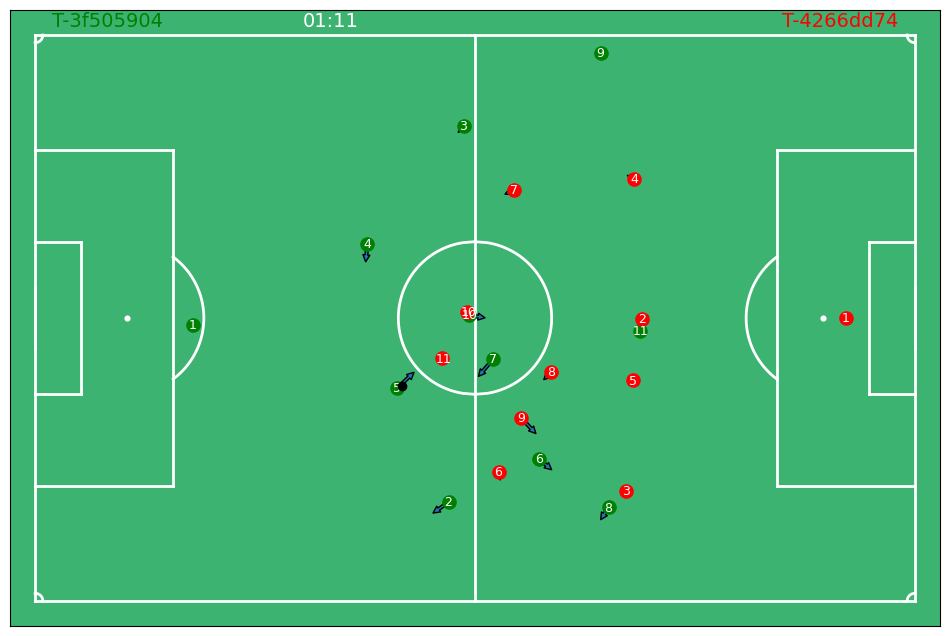

In [2]:
game = get_saved_game("synced_game", os.path.join(os.getcwd(), "../saved_games"))

game.tracking_data.add_velocity(game.get_column_ids() + ["ball"], allow_overwrite=True)
game.tracking_data.add_individual_player_possession()

selected_frame_idx = 1800
frame = game.tracking_data[game.tracking_data["frame"] == selected_frame_idx].iloc[0]
# frame id is not the same as index
idx_relative_to_game = game.tracking_data[
    game.tracking_data["frame"] == selected_frame_idx
].index[0]

fig, ax = plot_tracking_data(
    game,
    idx_relative_to_game,
    team_colors=["green", "red"],
    add_velocities=True,
)

## Build objective terms and constraints

For this example, we will define an objective function containing two objective terms:

- `WeightedPitchControlObjective`: rewards pitch-control effects from defensive movement (weight = 1). The weigthed pitch control objective aims to maximise the product of [pitch control](https://databallpy.readthedocs.io/en/latest/features/space_occupation.html#gaussian-model-fernandez-born-2018) with [expected threat](https://databallpy.readthedocs.io/en/latest/features/xt_models.html).
- `PressureObjective`: rewards pressure on the attacking side (weight = 1). The pressure objective tries to maximise the sum of [pressure](https://databallpy.readthedocs.io/en/latest/features/pressure_page.html) applied on (a selection of) opponent team players.

We constrain the algorithm with `TTIConstraint` (`TTI` stands for time to intercept), so players are only moved to physically reachable locations within a given time-to-intercept window, in this case 1 second.

In [ ]:
objective_terms = [
    WeightedPitchControlObjective(
        game=game,
        frame=frame,
    ),
    PressureObjective(
        game=game,
        frame=frame,
        players_to_press=None # --> change this to column ids of which opponent players need to be pressed / guarded
    ),
]
weights = [1, 1]
constraints = [TTIConstraint(game, frame, max_time_to_intercept_seconds=1, reaction_time=0.1)]

## Run simulated annealing

Simulated annealing is an optimisation technique. Rather than always choosing the best immediate solution, it occasionally accepts worse solutions, allowing the search to escape local optima and explore a wider range of possibilities. As the algorithm progresses, this willingness to accept worse solutions gradually decreases, shifting the focus from exploration to refinement. This balance between exploration and exploitation makes simulated annealing a useful method for solving complex optimisation problems where finding the global optimum is difficult, such as dynamic football situations.

Now we call the optimization API with `SimulatedAnnealing` as the algorithm backend.

In [ ]:
result = optimize_tracking_frame(
    game=game,
    selected_frame_idx=selected_frame_idx,
    objective_terms=objective_terms,
    weights=weights,
    constraints=constraints,
    algorithm=SimulatedAnnealing,
    num_iterations=2000,
    random_state=42,
    verbose=True,
    log_interval=10,  # log best score every 100 iterations
    patience=200,  # stop if no improvement found in first 200 iterations
    defending_players_to_optimize=None # -> add a list of ids of defending players which are allowed to be changed in position
)

print("Best objective value:", result.best_result)

Simulated Annealing Optimization: 100%|██████████| 1999/1999 [00:38<00:00, 51.75it/s, best_score=161]

Best objective value: 160.6544297909522


## Visualize original vs optimized frame

Use the diff_frames method and convert the optimized frame into a small TrackingData object.

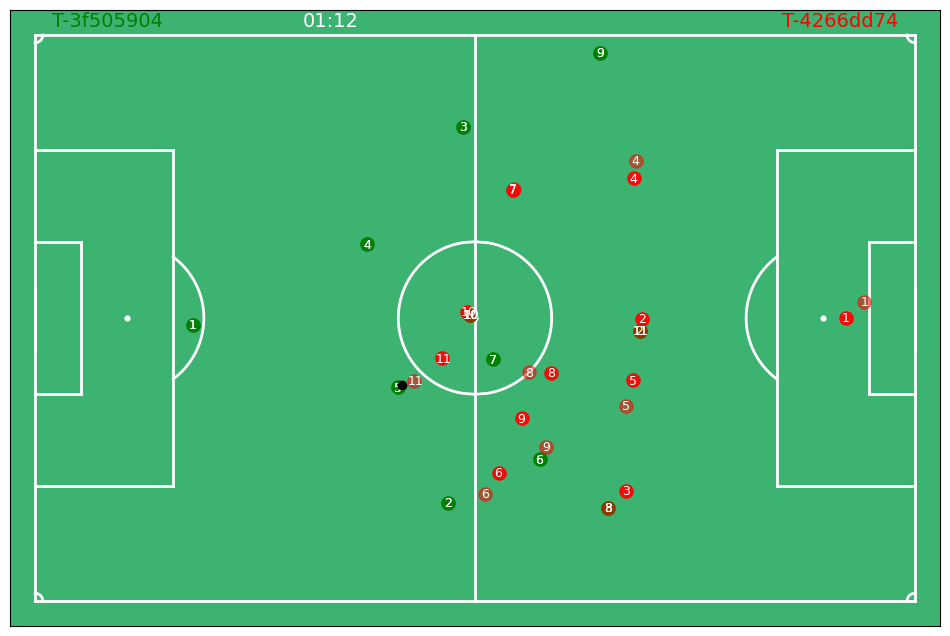

In [ ]:
fig, ax = diff_frames(
    game = game,
    frame_1_idx = selected_frame_idx,
    td_2 = pd.DataFrame(result.best_frame).transpose().astype(game.tracking_data.dtypes),
    frame_2_idx = selected_frame_idx,
    team_colors = ["green", "red"],
)
plt.show()

## What do we see?
We now see the original positions of the defending players (red) and the optimized position on the same frame (red, translucent). 

A few interesting observation emerge from this optimised frame for both pressure applied at the opponent and pitch control times xT. 
- To apply pressure, players are moved exactly on top an opponent (=max pressure applied), see for example number 2 and 3 of the red team
- Other players therefore change position to capture space, see for example number 5. 

You can discuss wether you thing this is a better positioning or not, but it is an interesting exercise to try to find an objective that mimics what you think is an optimal position. As for now, finding an optimum given an objective is no longer the problem, finding the right objective is.

## Conclusion

You now have a complete end-to-end example for frame-level tactical optimization with simulated annealing:

- loading and preparing tracking data,
- defining objective terms and constraints,
- running the optimizer,
- and comparing baseline vs optimized outcomes visually.

You can extend this setup by tuning objective weights, changing constraints, or plugging in additional optimization algorithms exposed by the optimization module.